In [1]:
import astropy.units as u
import astropy.coordinates as coord
import matplotlib.pyplot as plt
import numpy as np
import gala.dynamics as gd
import gala.potential as gp
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
from matplotlib.patches import Ellipse
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
from scipy.optimize import curve_fit

Helper Functions

In [2]:
def sample(dict, ics, n_samples=100):
    ra_samples = np.random.normal(dict['ra'], dict['e_ra'], n_samples)
    dec_samples = np.random.normal(dict['dec'], dict['e_dec'], n_samples)
    dist_samples = np.random.normal(dict['dist'], dict['e_dist'], n_samples)
    rv_samples = np.random.normal(dict['rv'], dict['e_rv'], n_samples)

    pmra_central = np.random.normal(dict['pmra'], dict['e_pmra'], 1)
    pmdec_central = np.random.normal(dict['pmdec'], dict['e_pmdec'], 1)
    pmra_samples = np.random.normal(pmra_central, dict['e_pmra']/20                                                                              , n_samples)
    pmdec_samples = np.random.normal(pmdec_central, dict['e_pmdec']/20                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       , n_samples)

    ics_list = []
    ics_list.append(ics)
    for ra, dec, dist, pmra, pmdec, rv in zip(ra_samples, dec_samples, dist_samples, pmra_samples, pmdec_samples, rv_samples):
        sc = coord.SkyCoord(ra=ra * u.degree,
                    dec=dec * u.degree,
                    distance=dist * u.kpc,
                    pm_ra_cosdec=pmra * (u.mas / u.yr),
                    pm_dec=pmdec * (u.mas / u.yr),
                    radial_velocity=rv * (u.km / u.s),
                    frame="icrs")
        gc = sc.transform_to(coord.Galactocentric)
        ics = gd.PhaseSpacePosition(pos=gc.cartesian.xyz, vel=gc.velocity.d_xyz)
        ics_list.append(ics)
    
    return ics_list

def calculate_orbits(dict, ics, num_steps):
    ics_list = sample(dict, ics)

    orbits = []
    for ics in ics_list:
        orbit = pot.integrate_orbit(ics, dt=-0.1*u.Myr, n_steps=num_steps)
        orbits.append(orbit)

    return orbits

def plot_ellipse(x_vals, y_vals, plane="XY"):
    pos = np.column_stack((x_vals, y_vals))
    mean = np.mean(pos, axis=0)
    cov = np.cov(pos, rowvar=False)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.scatter(x_vals, y_vals, s=3, color='red', alpha=0.5)

    # Confidence levels: 1σ (68%), 2σ (95%), 3σ (99.7%)
    for nsig in [1, 2, 3]:
        width, height = 2 * nsig * np.sqrt(eigvals)
        ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                          edgecolor='blue', fc='None', lw=2, label=f"{nsig}σ")
        ax.add_patch(ellipse)

    ax.set_xlabel(f"{plane[0]} [kpc]")
    ax.set_ylabel(f"{plane[1]} [kpc]")
    ax.grid(True)
    plt.tight_layout()
    plt.xlim(-40, 40)
    plt.ylim(-120, -20)
    plt.savefig('foreCraterII.png')
    plt.show()

def distance_mw(num_steps, ics):
    orbit = pot.integrate_orbit(ics, dt=-0.1*u.Myr, n_steps=num_steps)
    final_z = orbit[-1].pos.xyz.to(u.kpc).value[2]
    return abs(final_z)

def plot_closest(dict, ics, function, mw=False, target=[0,0,0]):
    ics_list = sample(dict, ics)

    k=3

    points = []
    times = []
    for ics in ics_list:
        result = minimize_scalar(
            function,
            args=(ics,),
            bounds=(0, 8000),  # search between 0 and 8000 steps (800 Myr)
            method='bounded'
        )
        orbit = pot.integrate_orbit(ics, dt=-0.1*u.Myr, n_steps=int(result.x))
        times.append(int(result.x)*0.1)
        final_pos = orbit[-1].pos.xyz.to(u.kpc).value[:k]
        points.append(final_pos)

    points = np.array(points)

    # if mw==True:
    #     x = points[:, 0]
    #     y = points[:, 1]

    #     plot_ellipse(x, y)
    # else:
    #     x = points[:, 0]
    #     y = points[:, 1]
    #     z = points[:, 2]

    #     plot_ellipse(x, y, "XY")
    #     # plot_ellipse(x, z, "XZ")
    #     # plot_ellipse(y, z, "YZ")

    # mahalanobis distance
    target = np.array(target)
    mean = np.mean(points, axis=0)
    cov = np.cov(points, rowvar=False)
    inv_cov = np.linalg.inv(cov)

    mahal_dist = mahalanobis(target, mean, inv_cov)
    
    p_value = 1 - chi2.cdf(mahal_dist**2, df=k)

    return p_value, times

First, define a gravitational potential.

In [3]:
pot = gp.MilkyWayPotential()

Crater II

In [4]:
dwarf_dict = {
    'ra': 177.310, #degree
    'e_ra': 0.03, #degree
    'dec': -18.413, #degree
    'e_dec': 0.03, #degree
    'dist': 117.5, #kpc
    'e_dist': 1.1, #kpc
    'pmra': -0.07, #mas/yr
    'e_pmra': 0.02, #mas/yr
    'pmdec': -0.11, #mas/yr
    'e_pmdec': 0.01, #mas/yr
    'rv': 87.5, #km/s
    'e_rv': 0.4, #km/s
    }
dwarf = coord.SkyCoord(
    ra=dwarf_dict['ra'] * u.degree,
    dec=dwarf_dict['dec'] * u.degree,
    distance=dwarf_dict['dist'] * u.kpc,
    pm_ra_cosdec=dwarf_dict['pmra'] * (u.mas / u.yr),
    pm_dec=dwarf_dict['pmdec'] * (u.mas / u.yr),
    radial_velocity=dwarf_dict['rv'] * (u.km / u.s),
    frame="icrs"
)
dwarf_GC = dwarf.transform_to(coord.Galactocentric)
dwarf_ics = gd.PhaseSpacePosition(pos=dwarf_GC.cartesian.xyz, vel=dwarf_GC.velocity.d_xyz)

        Use name instead. [gala.dynamics.core]


HVS 14

In [5]:
dict14 = {
    'ra': 161.0072805184, #degree
    'e_ra': 0.0001, #degree
    'dec': 6.1941762509, #degree
    'e_dec': 0.0001, #degree
    'dist': 102.66, #kpc
    'e_dist': 16.55, #kpc
    'pmra': -2.17, #mas/yr
    'e_pmra': 1.38, #mas/yr
    'pmdec': 2.28, #mas/yr
    'e_pmdec': 1.68, #mas/yr
    'rv': 537.30, #km/s
    'e_rv': 7.20, #km/s
    }
hvs14 = coord.SkyCoord(
    ra=dict14['ra'] * u.degree,
    dec=dict14['dec'] * u.degree,
    distance=dict14['dist'] * u.kpc,
    pm_ra_cosdec=dict14['pmra'] * (u.mas / u.yr),
    pm_dec=dict14['pmdec'] * (u.mas / u.yr),
    radial_velocity=dict14['rv'] * (u.km / u.s),
    frame="icrs"
)
hvs14_GC = hvs14.transform_to(coord.Galactocentric)
hvs14_ics = gd.PhaseSpacePosition(pos=hvs14_GC.cartesian.xyz, vel=hvs14_GC.velocity.d_xyz)

Milky Way Plot (z=0)

In [ ]:
count = 0
p_values_20 = []
for _ in range(10000):
    p_value, times = plot_closest(dict14, hvs14_ics, distance_mw, mw=True)
    # print(f"p_value: {p_value}")
    p_values_20.append(p_value)
    if p_value < 0.05:
        count += 1
print(f"count: {count}")

# Plot histogram
plt.hist(p_values_20, bins=10, edgecolor='black')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.title('Histogram of p-values')
plt.grid(True)
plt.show()

Milky Way f_mc Plot

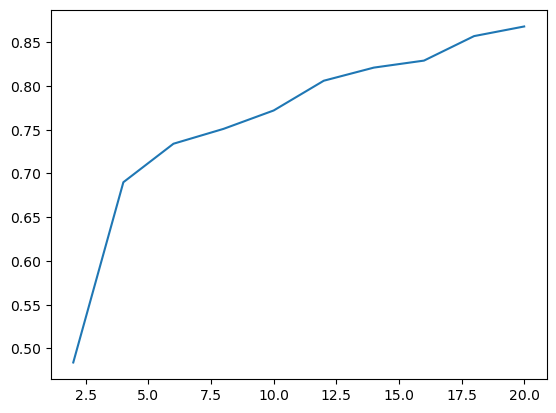

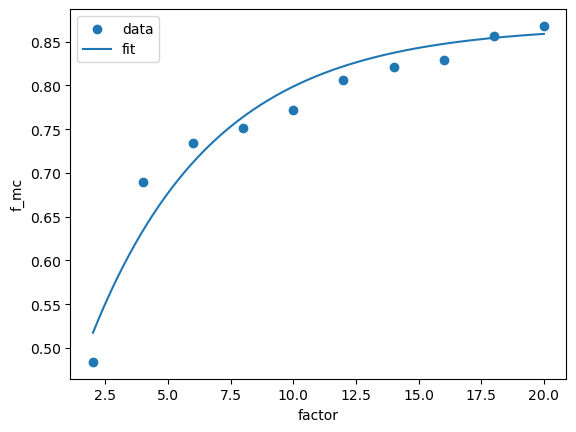

In [ ]:
# factor = [20, 16, 12, 8, 4]
# f_mc = []

# plt.plot(factor, f_mc)
# plt.show()

Milky Way p-value histogram

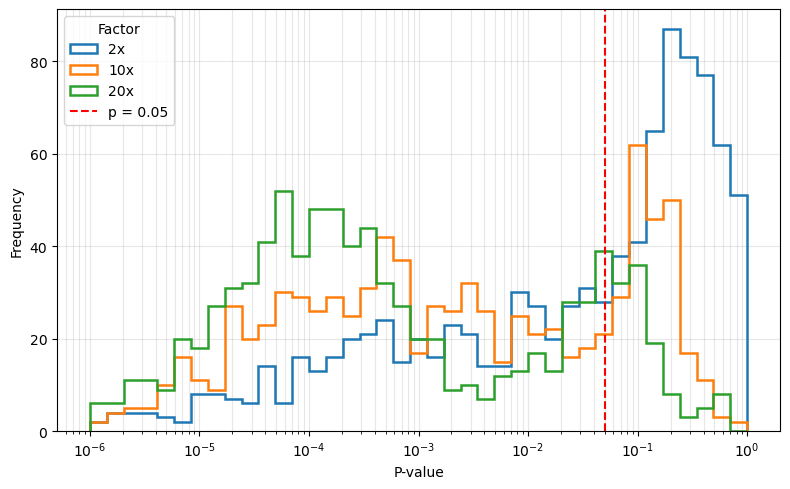

In [ ]:
# p4 = np.load("10000p_values_4.npy")
# p8 = np.load("10000p_values_8.npy")
# p12 = np.load("10000p_values_12.npy")
# p16 = np.load("10000p_values_16.npy")
# p20 = np.load("10000p_values_20.npy")

# series = {2: p2, 10: p10, 20: p20}

# all_pos = np.concatenate([v[np.isfinite(v) & (v > 0)] for v in series.values()])
# xmin = max(all_pos.min(), 1e-6)
# bins = np.logspace(np.log10(xmin), 0, 40)

# plt.figure(figsize=(8, 5))
# for f, vals in series.items():
#     vals = vals[np.isfinite(vals) & (vals > 0)]
#     plt.hist(vals, bins=bins, histtype="step", linewidth=1.8, label=f"{f}x")

# plt.xscale("log")
# plt.xlabel("P-value")
# plt.ylabel("Frequency")
# plt.axvline(0.05, color="red", linestyle="--", linewidth=1.5, label="p = 0.05")
# plt.legend(title="Factor")
# plt.grid(True, which="both", alpha=0.3)
# plt.tight_layout()
# plt.show()

Galaxy Plot

count: 904


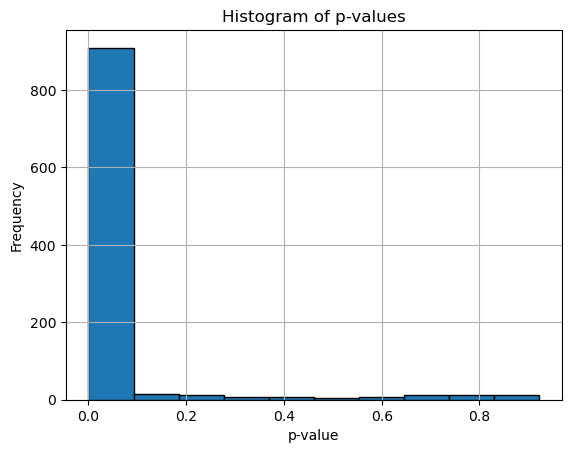

In [ ]:
min14 = 366.5427377870987

dwarf_orbits = calculate_orbits(dwarf_dict, dwarf_ics, min14)
points = []
for orbit in dwarf_orbits:
    final_pos = orbit[-1].pos.xyz.to(u.kpc).value[:3]
    points.append(final_pos)
points = np.array(points)
mean = np.mean(points, axis=0)

# print(f"mean: {mean}")

def distance_dwarf(num_steps, ics):
    orbit = pot.integrate_orbit(ics, dt=-0.1*u.Myr, n_steps=num_steps)
    final_pos = orbit[-1].pos.xyz.to(u.kpc).value[:3]
    distance = np.linalg.norm(final_pos - mean)
    return distance

count = 0
p_values_20_galaxy = []
for _ in range(10000):
    p_value, times = plot_closest(dict14, hvs14_ics, distance_dwarf, target=mean)
    # print(f"p_value: {p_value}")
    p_values_20_galaxy.append(p_value)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              
    if p_value < 0.05:
        count += 1
print(f"count: {count}")

# Plot histogram
plt.hist(p_values_20_galaxy, bins=10, edgecolor='black')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.title('Histogram of p-values')
plt.grid(True)
plt.show()

# # Plot histogram
# plt.hist(times, bins=10, edgecolor='black')
# plt.xlabel('Time (Myr)')
# plt.ylabel('Frequency')
# plt.title('Histogram of Times')
# plt.grid(True)
# plt.show()

Galacy f_mc Plot

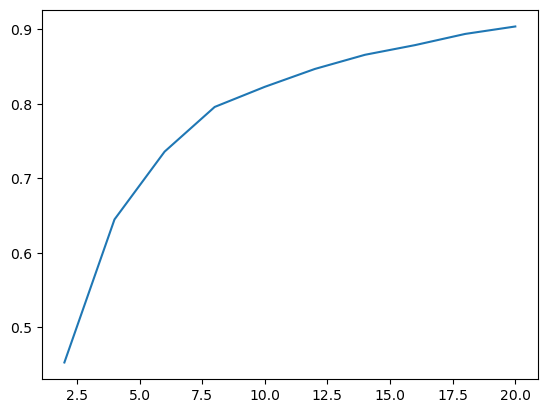

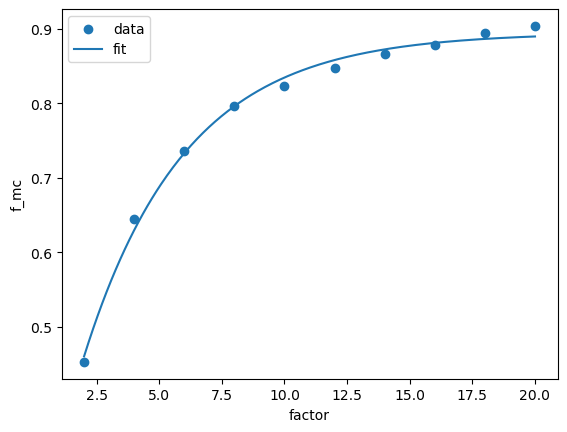

In [ ]:
factor = [20, 18, 16, 14, 12, 10, 8, 6, 4, 2]
f_mc = [0.904, 0.894, 0.879, 0.866, 0.847, 0.823, 0.796, 0.736, 0.645, 0.453]

plt.plot(factor, f_mc)
plt.show()

print(p_values_20)
np.save('10000p_values_20.npy', np.array(p_values_20))
print(p_values_20_galaxy)
np.save('10000p_values_20_galaxy.npy', np.array(p_values_20_galaxy))